In [9]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Features + target as a single DataFrame
df = housing.frame

# Quick check
print(df.head())
print(df.shape)

# Split-out validation df
X = df.drop('MedHouseVal', axis=1) #covariates - just drop the target!
y = df['MedHouseVal'] #target variable
validation_size = 0.20
seed = 123 # so you will split the same way and evaluate the SAME dataset

# split!
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=validation_size, random_state=seed)
print(X_train.shape)
print(X_test.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)
(16512, 8)
(4128, 8)


In [10]:
from sklearn.neural_network import MLPRegressor

# MLPRegressor with hidden_layer and early stopping
mlp = MLPRegressor(
    random_state=42,
    hidden_layer_sizes=(10, 5),
    max_iter=1000,
    batch_size=1000,
    activation="relu",
    early_stopping=True
)

mlp.fit(X_train, Y_train)

MLPRegressor(batch_size=1000, early_stopping=True, hidden_layer_sizes=(10, 5),
             max_iter=1000, random_state=42)

In [11]:
#Training data results
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
cv_results = cross_val_score(mlp, X_train, Y_train, cv=kfold, scoring='neg_mean_squared_error')

-0.9371142201424029
0.5055191123598511


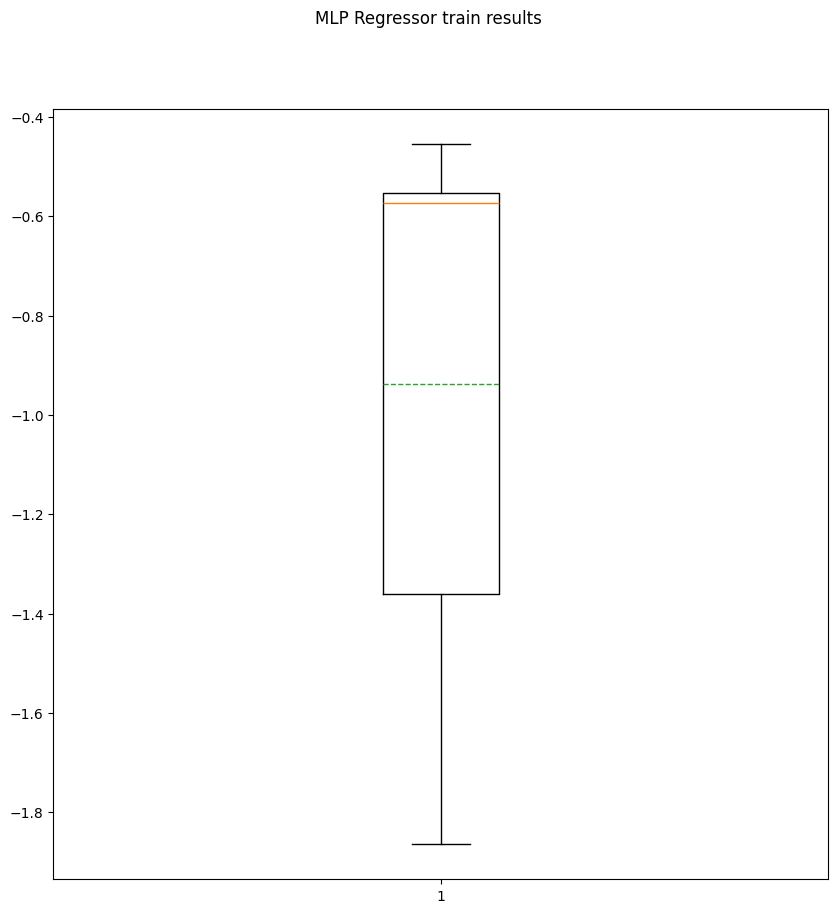

In [21]:
#Print the training results mean and standard deviation
print(cv_results.mean())
print(cv_results.std())
#Display the training results in a boxplot
plt.boxplot(cv_results, showmeans=True, meanline=True)
plt.suptitle('MLP Regressor train results')
plt.rcParams["figure.figsize"] = (10,10)
plt.show()